<a href="https://colab.research.google.com/github/JuanZapa7a/AINavalEngineering/blob/main/CS2-Yacht_Hydrodynamics_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Yatch Hydrodynamics Dataset**

The **Yacht Hydrodynamics Dataset** is a dataset widely used in regression and machine learning projects. It is available at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/yacht+hydrodynamics), [github](https://github.com/ajx42/Yacht-Hydrodynamics-Linear-Regression-?utm_source=chatgpt.com), [mlbazaar](https://mlbazaar.github.io/dataset/LL0-uci-yacht-hydrodynamics?utm_source=chatgpt.com). The Yacht Hydrodynamics Dataset is a classic regression dataset used in naval hydrodynamics to predict the residuary resistance of yacht hulls based on geometric and dynamic parameters.

## **Overview**  
This dataset, also known as the *Delft dataset*, originates from the **Delft Ship Hydromechanics Laboratory**. It was used to predict the **hydrodynamic performance** of sailing yachts based on their dimensions and speed. The dataset contains **308 full-scale experiments** conducted with **22 different hull forms**, derived from a base design similar to the "Standfast 43" by designer Frans Maas.  

## **Dataset Structure**  

- **Instances**: 308  
- **Predictor variables** (all dimensionless):  
  1. Longitudinal position of the center of buoyancy  
  2. Prismatic coefficient  
  3. Length-displacement ratio  
  4. Beam-draught ratio  
  5. Length-beam ratio  
  6. Froude number  
- **Target variable**: Residuary resistance per unit weight of displacement  
- **Missing values**: None *(Source: Turnock et al.)*  

## **Common Applications**  

This dataset is frequently used to:  
- Evaluate linear and nonlinear regression models.  
- Apply neural networks and machine learning techniques to predict residuary resistance.  
- Study the relationship between hull geometric parameters and hydrodynamic performance.  

*For example, [Neural Designer](https://www.neuraldesigner.com/learning/examples/yacht-hydrodynamics-modeling/) built a machine learning model to predict yacht hydrodynamic performance based on hull geometry coefficients and the Froude number.*  

## **Access and Additional Resources**  

- **Direct download**: Available via the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/yacht+hydrodynamics).  
- **Python implementations**: See examples on GitHub, like [this repository](https://github.com/ajx42/Yacht-Hydrodynamics-Linear-Regression), which applies linear regression using NumPy, Statsmodels, and Matplotlib.  


##Setting up Our Workspace

---
**Setting our Home**

---

_``We save the root directory of our workspace``_  as `'HOME'` since we will be navigating through the directory to have multiple projects under the same HOME. Additionally, ``we will have the datasets in the 'Datasets' directory``, so all datasets are easily accessible for any project.

In [ ]:
# Setting our $HOME to /content
import os
HOME = os.getcwd() # Obtain actual directory
print(HOME)

/workspaces/AINavalEngineering



---
**Create a directory where we can save our dataset**

---

In [ ]:
# Create the dataset directory
datasets_dir = os.path.join(HOME, "Datasets")
os.makedirs(datasets_dir, exist_ok=True)
print(os.getcwd())

/workspaces/AINavalEngineering



---
**Change to new datasets directory**

---

In [ ]:
# Change to new dataset folder
os.chdir(datasets_dir)
print('dataset_dir =', os.getcwd())
!wget -q wget tent/sample_data/yacht_hydrodynamics.data https://archive.ics.uci.edu/ml/machine-learning-databases/00243/yacht_hydrodynamics.data


dataset_dir = /workspaces/AINavalEngineering/Datasets


## Load the Dataset

In this step we are going to load the dataset and the naval data file from URL.

In [ ]:
import numpy
from numpy import arange
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from scipy import stats

---
**Load the dataset**

---

In [ ]:
import pandas as pd

# Load the dataset
filename = item_path = os.path.join(datasets_dir,'yacht_hydrodynamics.data')

# Column names based on the dataset description
column_names = [
    "Longitudinal_position_of_COB",  # Center of Buoyancy
    "Prismatic_coefficient",
    "Length_displacement_ratio",
    "Beam_draught_ratio",
    "Length_beam_ratio",
    "Froude_number",
    "Residuary_resistance"
]


# Load the dataset
df = pd.read_csv(filename, sep=r'\s+', names=column_names)

# Preview the first few rows
print(df.head())


   Longitudinal_position_of_COB  Prismatic_coefficient  \
0                          -2.3                  0.568   
1                          -2.3                  0.568   
2                          -2.3                  0.568   
3                          -2.3                  0.568   
4                          -2.3                  0.568   

   Length_displacement_ratio  Beam_draught_ratio  Length_beam_ratio  \
0                       4.78                3.99               3.17   
1                       4.78                3.99               3.17   
2                       4.78                3.99               3.17   
3                       4.78                3.99               3.17   
4                       4.78                3.99               3.17   

   Froude_number  Residuary_resistance  
0          0.125                  0.11  
1          0.150                  0.27  
2          0.175                  0.47  
3          0.200                  0.78  
4          0.225   

1. The dataset uses whitespace as the delimiter, so delim_whitespace=True (deprecated by sep=r'\s+') is needed.

2. There are no missing values, so you can go straight into exploration or modeling after this.


## Summarize the Dataset

We can now take a closer look at our loaded data. We can get a quick idea of how many instances (rows) and how many attributes (columns) the
data contains with the shape property.

---
**Data Shape**

---

In [ ]:
# shape
print(df.shape)

(308, 7)


We have 308 instances to work with and can confirm the data has 7 attributes.

---
**Data Types**

---

In [ ]:
# types
print(df.dtypes)

Longitudinal_position_of_COB    float64
Prismatic_coefficient           float64
Length_displacement_ratio       float64
Beam_draught_ratio              float64
Length_beam_ratio               float64
Froude_number                   float64
Residuary_resistance            float64
dtype: object


---
**Show first rows**

---

It is also always a good idea to actually eyeball your data.

In [ ]:
# head
print(df.head(20))

    Longitudinal_position_of_COB  Prismatic_coefficient  \
0                           -2.3                  0.568   
1                           -2.3                  0.568   
2                           -2.3                  0.568   
3                           -2.3                  0.568   
4                           -2.3                  0.568   
5                           -2.3                  0.568   
6                           -2.3                  0.568   
7                           -2.3                  0.568   
8                           -2.3                  0.568   
9                           -2.3                  0.568   
10                          -2.3                  0.568   
11                          -2.3                  0.568   
12                          -2.3                  0.568   
13                          -2.3                  0.568   
14                          -2.3                  0.569   
15                          -2.3                  0.569 

---
**Statistical Summary**

---

Now we can take a look at a summary of each attribute. This includes the count, mean, the min and max values as well as some percentiles.



In [ ]:
# Statistical Summary
print(pd.DataFrame(df).describe())

       Longitudinal_position_of_COB  Prismatic_coefficient  \
count                    308.000000             308.000000   
mean                      -2.381818               0.564136   
std                        1.513219               0.023290   
min                       -5.000000               0.530000   
25%                       -2.400000               0.546000   
50%                       -2.300000               0.565000   
75%                       -2.300000               0.574000   
max                        0.000000               0.600000   

       Length_displacement_ratio  Beam_draught_ratio  Length_beam_ratio  \
count                 308.000000          308.000000         308.000000   
mean                    4.788636            3.936818           3.206818   
std                     0.253057            0.548193           0.247998   
min                     4.340000            2.810000           2.730000   
25%                     4.770000            3.750000           3.1

**1. Longitudinal Position of COB (Center of Buoyancy)**
- **Range**: `-5.0` to `0.0` (dimensionless)
- **Mean**: `-2.38` ± `1.51` (high variability)
- **Distribution**:  
  - 50% of values cluster around `-2.4` to `-2.3` (left-skewed).  
  - Minimum (`-5.0`) is an outlier compared to the IQR.

**2. Prismatic Coefficient**
- **Range**: `0.53` to `0.60` (dimensionless)
- **Mean**: `0.564` ± `0.023` (low variability)
- **Insight**:  
  - Tight distribution (std ≈ 2.3% of mean), suggesting hull designs follow similar volumetric efficiency principles.

**3. Length-Displacement Ratio**
- **Range**: `4.34` to `5.14`
- **Mean**: `4.79` ± `0.25`
- **Notable**:  
  - 75th percentile (`5.1`) close to max (`5.14`), indicating few high-ratio designs.

**4. Beam-Draught Ratio**
- **Range**: `2.81` to `5.35`
- **Mean**: `3.94` ± `0.55`
- **Interpretation**:  
  - Wider spread (std ≈ 14% of mean) reflects diverse hull shapes (e.g., shallow vs. deep drafts).

**5. Length-Beam Ratio**
- **Range**: `2.73` to `3.64`
- **Mean**: `3.21` ± `0.25`
- **Pattern**:  
  - 50% of yachts have a ratio of `3.15` (common design stability standard).

**6. Froude Number**
- **Range**: `0.125` to `0.45`
- **Mean**: `0.288` ± `0.101`
- **Implications**:  
  - Values < `0.4` suggest most tests were in *displacement mode* (non-planing hulls).

**7. Residuary Resistance (Target Variable)**
- **Range**: `0.01` to `62.42` (unit: per weight of displacement)
- **Mean**: `10.50` ± `15.16`
- **Distribution**:  
  - Highly right-skewed (mean ≫ median `3.065`).  
  - 75th percentile (`12.82`) << max (`62.42`), indicating extreme outliers (possible high-speed/high-resistance cases).

### **Critical Insights**
1. **Outliers Alert**:  
   - `Residuary_resistance` has extreme values (max ≈ 10× 75th percentile). Consider log-transform for regression models.
2. **Design Uniformity**:  
   - Low std in `Prismatic_coefficient` and `Length_beam_ratio` implies standardized hull design practices.
3. **Speed Regimes**:  
   - `Froude_number` suggests most data is for low-speed hydrodynamics (sub-critical flow).

### **Recommendations for Modeling**
- **Preprocessing**:  
  - Scale features (e.g., `StandardScaler` due to varying ranges).  
  - Log-transform the target variable to handle skewness.
- **Feature Importance**:  
  - Prioritize `Beam_draught_ratio` and `Froude_number` (higher variability likely correlates with resistance).
- **Algorithms**:  
  - Start with **Random Forest** or **Gradient Boosting** to handle non-linear relationships.

### **Python Quick Check for Skewness**
```python
import seaborn as sns
sns.histplot(data=df, x="Residuary_resistance", kde=True)
```
*Expected: Heavy right tail → confirm log-transform need.*


---
**Check Skewness**

---

<Axes: xlabel='Residuary_resistance', ylabel='Count'>

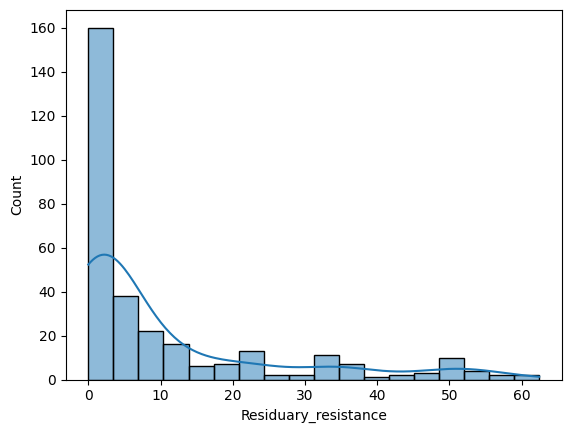

In [ ]:
import seaborn as sns
sns.histplot(data=df, x="Residuary_resistance", kde=True)

## Data Visualization

We now have a basic idea about the data. We need to extend this with some visualizations. We
are going to look at two types of plots:
- Univariate plots to better understand each attribute.
- Multivariate plots to better understand the relationships between attributes.


---
**Univariate Plots: Histogram**

---

Let’s look at visualizations of individual attributes. It is often useful to look at your data
using multiple different visualizations in order to spark ideas. Let’s look at histograms of each
attribute to get a sense of the data distributions.

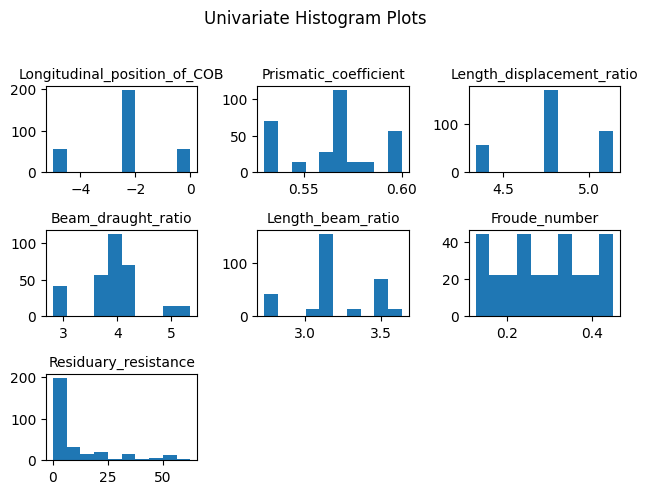

In [ ]:
import matplotlib.pyplot as plt

# Calculate the number of rows and columns for subplots
num_cols = df.shape[1]  # Number of columns in the DataFrame
num_rows = (num_cols + 2) // 3  # Calculate rows, ensuring enough space

# Create figure and axes with the correct number of subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=3)

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot histograms, ensuring you iterate over all columns
for i, col in enumerate(df.columns):
    df.hist(column=col,
            ax=axes[i],
            sharex=False,
            sharey=False,
            grid=False,
            #xlabelsize=12,
            #ylabelsize=12
            )
    axes[i].set_title(col, fontsize=10)

# Hide any unused subplots (if num_cols is not divisible by 3)
for i in range(num_cols, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Univariate Histogram Plots', y=1.02)
plt.tight_layout()
plt.show()

| **Feature**                     | **Distribution**                                               | **Observation**                                                                 |
|---------------------------------|----------------------------------------------------------------|---------------------------------------------------------------------------------|
| Longitudinal_position_of_COB   | Strong peak around -2 to -2.5; smaller peaks near 0 and -5     | Most yachts have similar COB positions; some variation suggests different designs |
| Prismatic_coefficient          | Bimodal: peaks around 0.53 and 0.57                            | Mix of fine and fuller hull forms, likely balancing speed vs. stability         |
| Length_displacement_ratio      | Centered around 4.8                                            | Indicates moderately slender hulls; suitable for efficient speed                |
| Beam_draught_ratio             | Peak around 4.0                                                | Common yacht proportions; balance between stability and speed                   |
| Length_beam_ratio              | Strong peak at 3.2                                             | Reflects long, slender hulls optimized for hydrodynamic efficiency              |
| Froude_number                  | Uniformly distributed between 0.14 and 0.44                    | Wide range of operational speeds covered; suitable for general-purpose modeling |
| Residuary_resistance           | Right-skewed (long tail)                                       | Most cases have low resistance; some extreme outliers with high resistance      |

**Why Skewed Gaussian Distributions Are Problematic**

1. Many algorithms (e.g., linear regression, Gaussian Naive Bayes, PCA) assume data is normally distributed. Skew violates this assumption, leading to biased results.

2. Models like logistic regression and SVMs may underperform if features have heavy tails or outliers. Skewed data often has outliers, which can disproportionately influence model training (e.g., MSE loss in regression).


---
**Univariate Plots: Density**

---


Let’s look at the same distributions using density plots that smooth them out a bit.

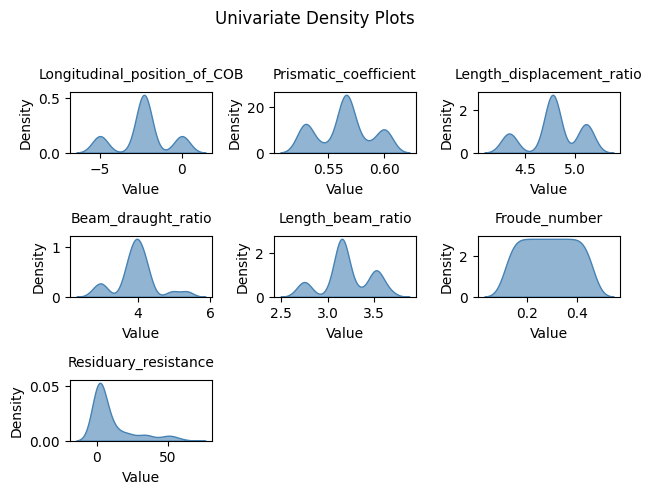

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set up subplot grid
n_cols = 3
n_rows = int(np.ceil(len(df.columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols)  # Larger figure for big fonts

# Flatten axes array for easy iteration
axes = axes.ravel()

# Create density plots
for ax, column in zip(axes, df.columns):
    sns.kdeplot(data=df[column],
                ax=ax,
                fill=True,
                color='steelblue',
                alpha=0.6)

    # Formatting with your specified font sizes
    ax.set_title(column, fontsize=10, pad=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.tick_params(axis='both')
    ax.grid(False)

# Hide empty subplots
for i in range(len(df.columns), len(axes)):
    axes[i].axis('off')

# Main title and layout
plt.suptitle('Univariate Density Plots', y=1.02)
plt.tight_layout()  # Increased padding for large fonts
plt.show()

A brief analysis of the **Univariate Density Plots** in a table format:

| **Feature**                   | **Density Shape**                                           | **Insights**                                                                 |
|------------------------------|--------------------------------------------------------------|------------------------------------------------------------------------------|
| Longitudinal_position_of_COB | Trimodal distribution with main peak around -2              | Suggests three common hull design clusters based on COB position             |
| Prismatic_coefficient        | Trimodal, peaks near 0.53, 0.57, and 0.60                    | Reflects design variation between fine and fuller hulls                      |
| Length_displacement_ratio    | Trimodal, with peaks around 4.3 , 4,7 and 5.2.0                       | Indicates distinct yacht types (3?)    |
| Beam_draught_ratio           | Trimodal, strong peak near 4.0                                | Shows majority of yachts share similar proportions, with some outliers       |
| Length_beam_ratio            | Trimodal, dominant peak around 3.2                            | Common slender hull designs, but some variation present                      |
| Froude_number                | Uniform distribution with slight tapering at edges          | Dataset samples speeds evenly across range; good for modeling across regimes |
| Residuary_resistance         | Right-skewed with long tail                                 | Most yachts exhibit low resistance; some high-resistance cases as outliers   |

---
**Univariate Plots: Whisker Plot**

---

Let’s look at the data with box and whisker plots of each attribute.

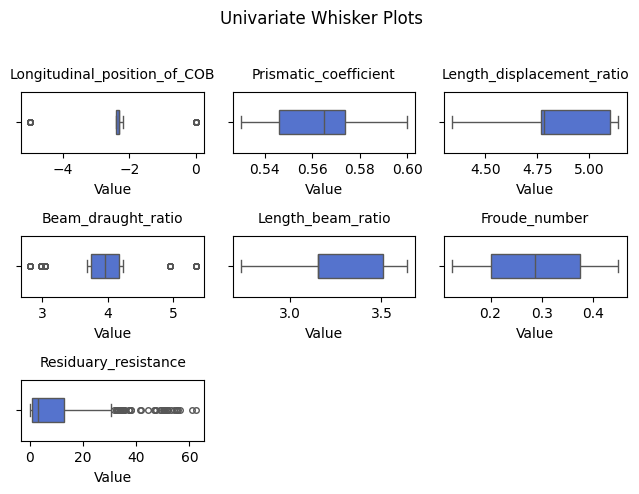

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up subplot grid
n_cols = 3
n_rows = int(np.ceil(len(df.columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols)

# Flatten axes array for easy iteration
axes = axes.ravel()

# Create box plots for each column
for ax, column in zip(axes, df.columns):
    sns.boxplot(x=df[column],
                ax=ax,
                color='royalblue',
                width=0.4,
                fliersize=4)  # Outlier marker size

    # Formatting with large fonts
    ax.set_title(column, fontsize=10, pad=10)
    ax.set_xlabel('Value')
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')

    # Remove y-axis for cleaner look (univariate)
    ax.set_ylabel('')
    ax.grid(False)

# Hide empty subplots
for i in range(len(df.columns), len(axes)):
    axes[i].axis('off')

# Main title and layout
plt.suptitle('Univariate Whisker Plots', y=1.02)
plt.tight_layout()  # Extra padding for large fonts
plt.show()

| **Feature**                   | **Spread & Outliers**                                         | **Insights**                                                                 |
|------------------------------|---------------------------------------------------------------|------------------------------------------------------------------------------|
| Longitudinal_position_of_COB | Narrow IQR, several outliers on both sides                    | Highly concentrated COB positions; few designs deviate significantly         |
| Prismatic_coefficient        | Moderate spread, symmetric, no major outliers                 | Balanced variation in hull fullness; well-controlled range                   |
| Length_displacement_ratio    | Slightly right-skewed, wider IQR                              | Most yachts centered around 4.8–5.0, some variation toward higher values     |
| Beam_draught_ratio           | Moderate spread, multiple outliers                            | Consistent proportions but with occasional extreme hull forms                |
| Length_beam_ratio            | Moderate spread, few outliers                                 | Most yachts maintain similar slenderness ratios                              |
| Froude_number                | Uniform IQR, no significant outliers                          | Speed ratios are evenly distributed; no extreme operational cases            |
| Residuary_resistance         | Highly skewed right, many outliers                            | Most yachts show low resistance; frequent high-resistance anomalies exist    |


---
**Multivariate Plots: Correlation**

---

Now, let’s now take a look at the correlation between all of the numeric attributes.

In [ ]:
# correlation
pd.set_option('display.precision', 2)
print(df.corr(method='pearson'))

                              Longitudinal_position_of_COB  \
Longitudinal_position_of_COB                      1.00e+00   
Prismatic_coefficient                            -8.61e-03   
Length_displacement_ratio                        -2.67e-03   
Beam_draught_ratio                                2.93e-03   
Length_beam_ratio                                -3.37e-03   
Froude_number                                    -3.51e-18   
Residuary_resistance                              1.93e-02   

                              Prismatic_coefficient  \
Longitudinal_position_of_COB              -8.61e-03   
Prismatic_coefficient                      1.00e+00   
Length_displacement_ratio                 -4.63e-02   
Beam_draught_ratio                         3.39e-01   
Length_beam_ratio                         -8.67e-02   
Froude_number                              2.91e-16   
Residuary_resistance                      -2.86e-02   

                              Length_displacement_ratio  Beam_

In text mode output format it is difficult to visualise the strongest correlations.

---
**Plotting correlation like a heatmap**

---

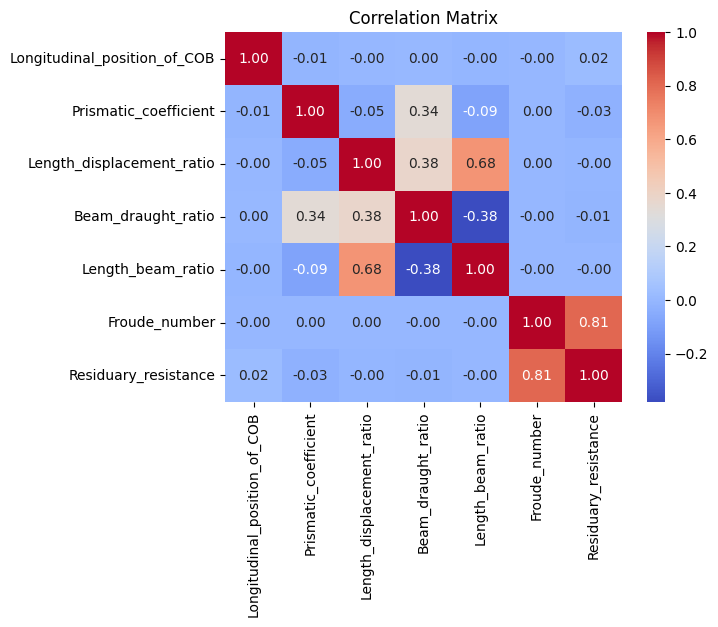

In [ ]:
# Plotting correlation matrix as a heatmap
plt.figure()
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

**Strong Correlations (|r| > 0.5)**
1. **Froude_number ↔ Residuary_resistance**  
   - **Correlation**: +0.81  
   - **Interpretation**: Very strong positive relationship. As the Froude number (speed parameter) increases, residuary resistance increases significantly. This is expected in naval architecture as higher speeds generate more wave resistance.

2. **Length_displacement_ratio ↔ Length_beam_ratio**  
   - **Correlation**: +0.68  
   - **Interpretation**: Moderate-strong positive link. Longer/narrower hulls (higher length-beam ratio) tend to have higher length-displacement ratios (slender designs).

3. **Length_displacement_ratio ↔ Beam_draught_ratio**  
   - **Correlation**: +0.38  
   - **Interpretation**: Moderate positive relationship. Slender hulls (high length-displacement) often have wider/shallower drafts.

4. **Beam_draught_ratio ↔ Length_beam_ratio**
  - **Correlation**: -0.38
  - **Interpretation**: Wider hulls (high beam-draught ratio) tend to be shorter relative to their width (low length-beam ratio).



---
**Plotting the strongest correlation**

---

It visually demonstrates the strongest relationship (correlation) between two variables in your dataset using a scatter plot with a linear regression line.
1. The red regression line shows the trend, and the scatter points (with transparency alpha=0.5) display the actual data distribution.
2. The correlation coefficient (r = 0.81), indicating a strong positive linear relationship.
3. The scatter points curve around the line, a polynomial or log transform might improve the model.

Text(0.5, 1.0, 'Froude Number vs. Resistance (r = 0.81)')

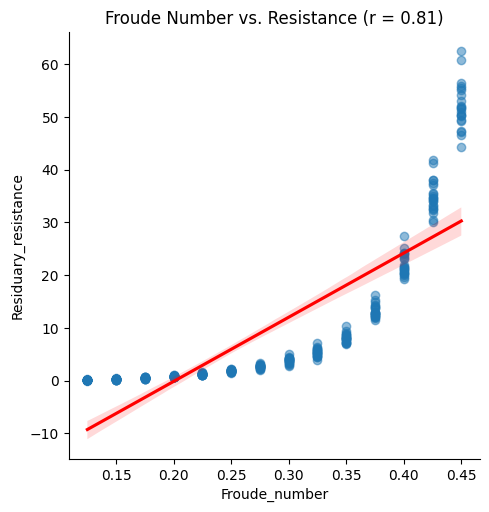

In [ ]:
# Plot strongest relationship
sns.lmplot(data=df, x='Froude_number', y='Residuary_resistance',
           scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Froude Number vs. Resistance (r = 0.81)')

**Hydrodynamic Interpretation**

As Froude number (Fn) increases:

- Wave-making resistance grows exponentially

- Hull transitions from displacement to semi-planing mode

- Pressure drag becomes dominant

---
**Multivariate Plots: scatter plot**

---

Now we can look at the interactions between the variables. Let’s look at scatter plots of all
pairs of attributes. This can be helpful to spot structured relationships between input variables.

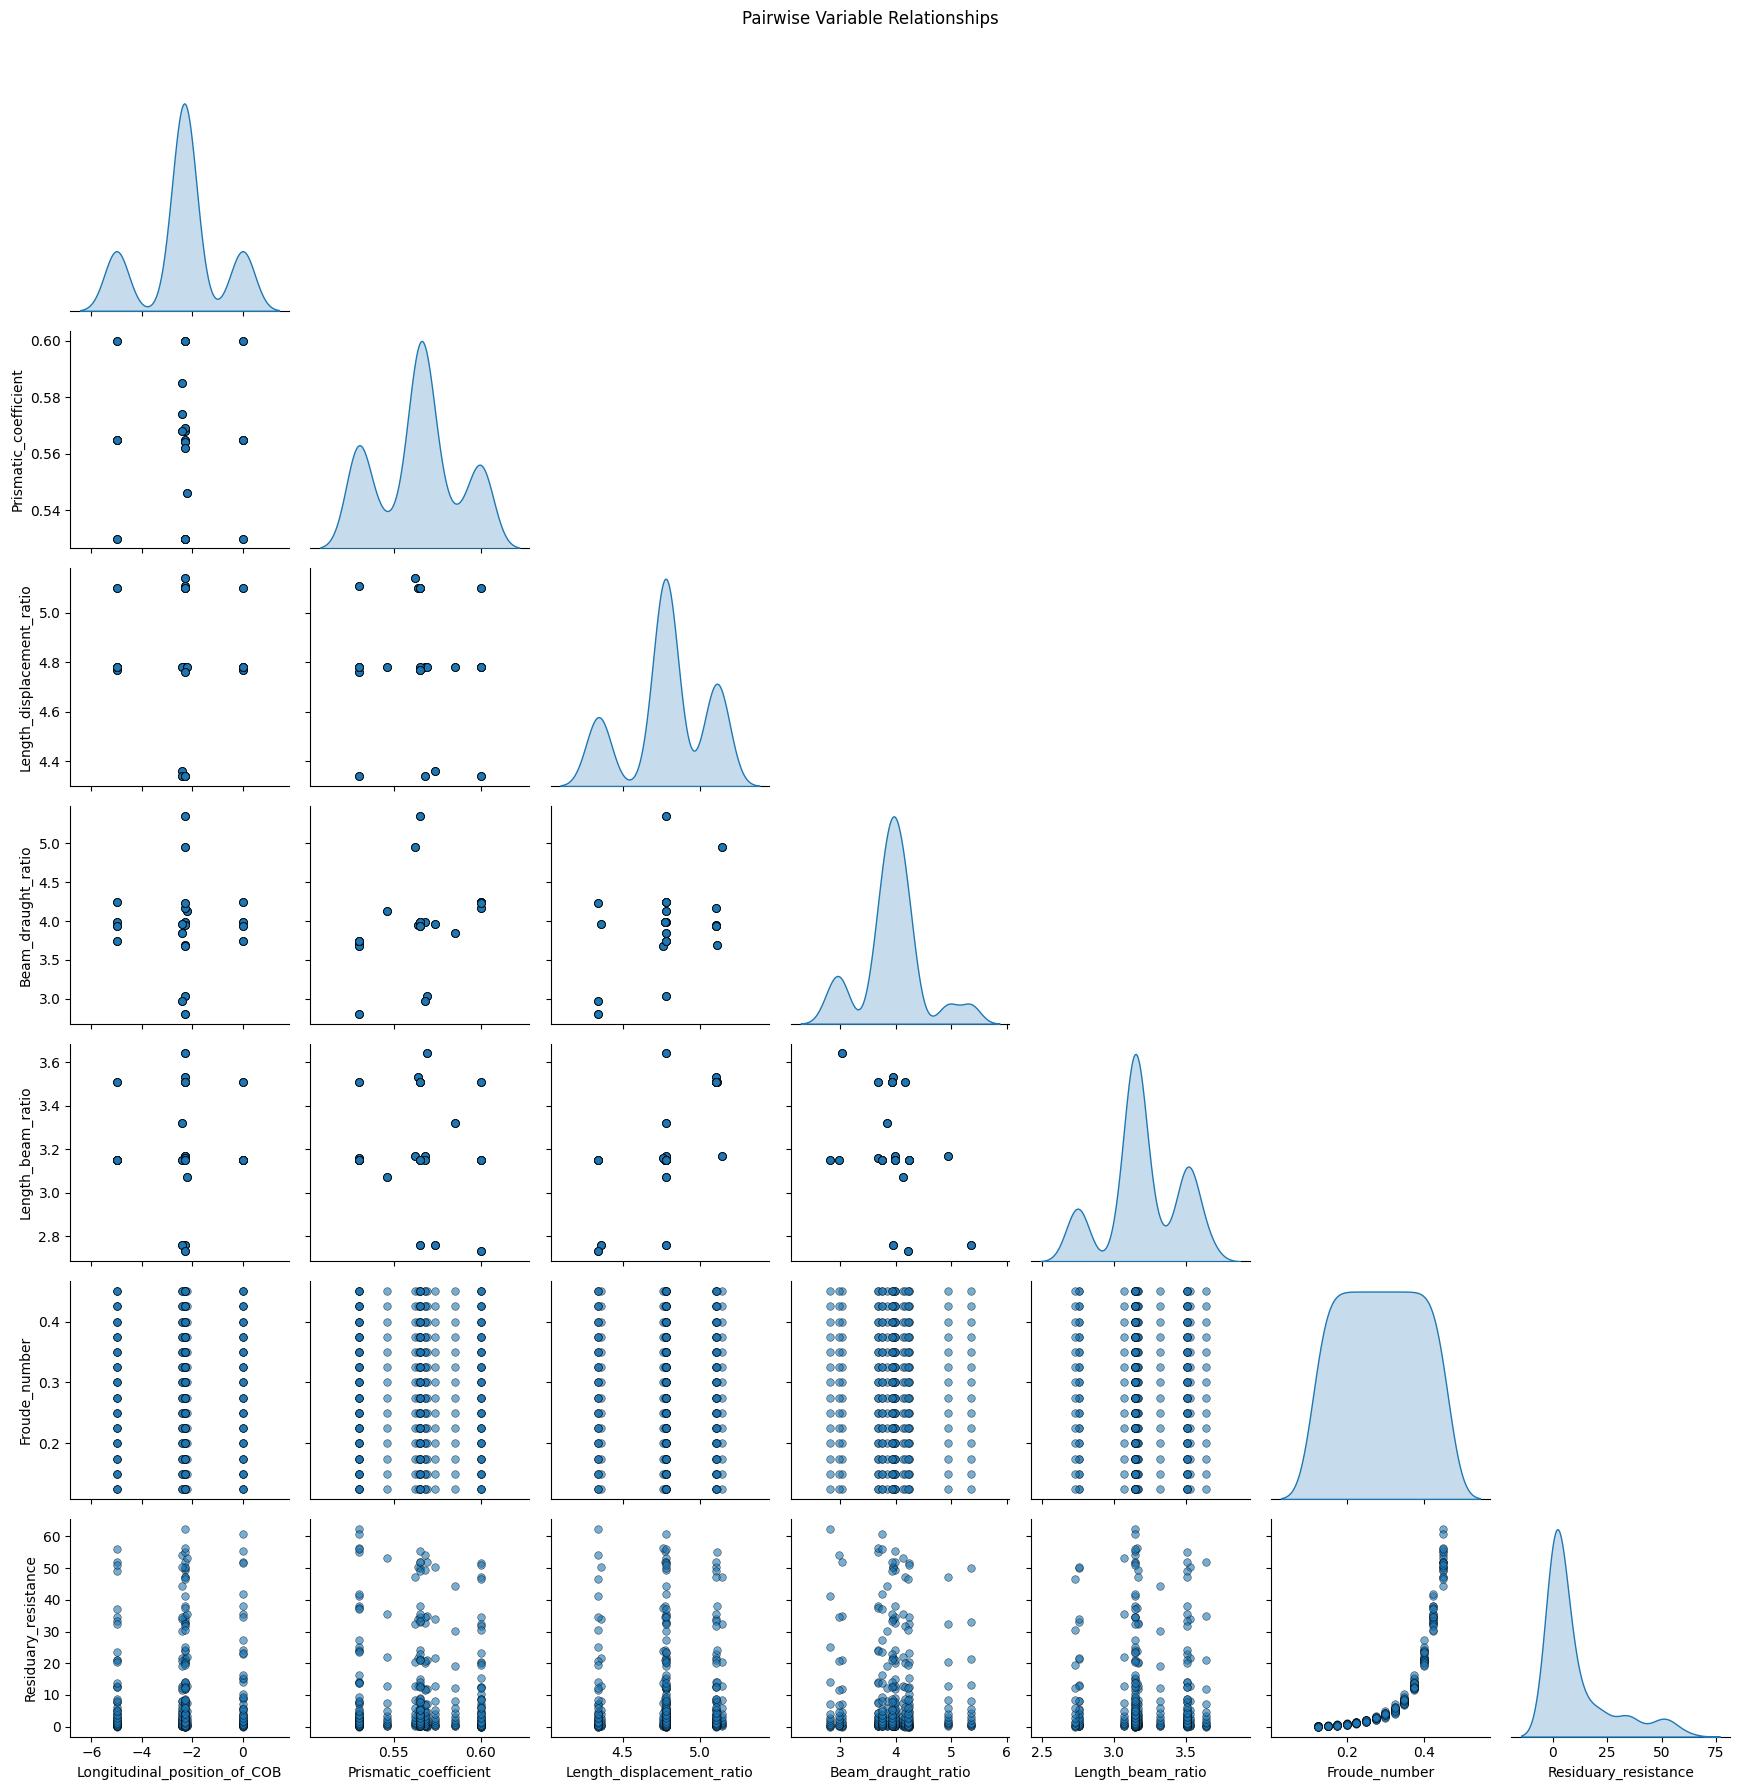

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create pairplot with custom styling
g = sns.pairplot(df,
                 diag_kind='kde',
                 plot_kws={'alpha':0.6, 's':30, 'edgecolor':'k'},
                 corner=True)  # Shows lower triangle only

# Enhance readability
plt.suptitle("Pairwise Variable Relationships", y=1.02)

# Adjust marker transparency and size
# for ax in g.axes.flatten():
#     if ax:
#         ax.xaxis.label.set_size(10)
#         ax.yaxis.label.set_size(10)
#         ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

This image is a **pairplot** (or scatterplot matrix), commonly used in exploratory data analysis (EDA) to visualize pairwise relationships between multiple numerical variables. Here's a breakdown of what it shows and how to interpret it:

**Strong Relationship**:
- **`Froude_number` vs `Residuary_resistance`**: There is a clear exponential-like increase in resistance with increasing Froude number — which makes physical sense, as wave-making resistance increases rapidly in that regime.

**Weak/No Relationship**:
- `Longitudinal_position_of_COB` seems to have no clear correlation with most other variables.
- `Prismatic_coefficient` and `Beam_draught_ratio` appear relatively scattered across most pairings.

**Possible Patterns**:
- **`Length_displacement_ratio` vs `Beam_draught_ratio`** and `Length_beam_ratio`: slight structure that could be worth exploring with correlation coefficients.
- **`Prismatic_coefficient`** has a narrow distribution range and might not be a strong influencer for all relationships shown.


---
**A better (enhanced) correlation pairplot with Statistical Annotations**

---

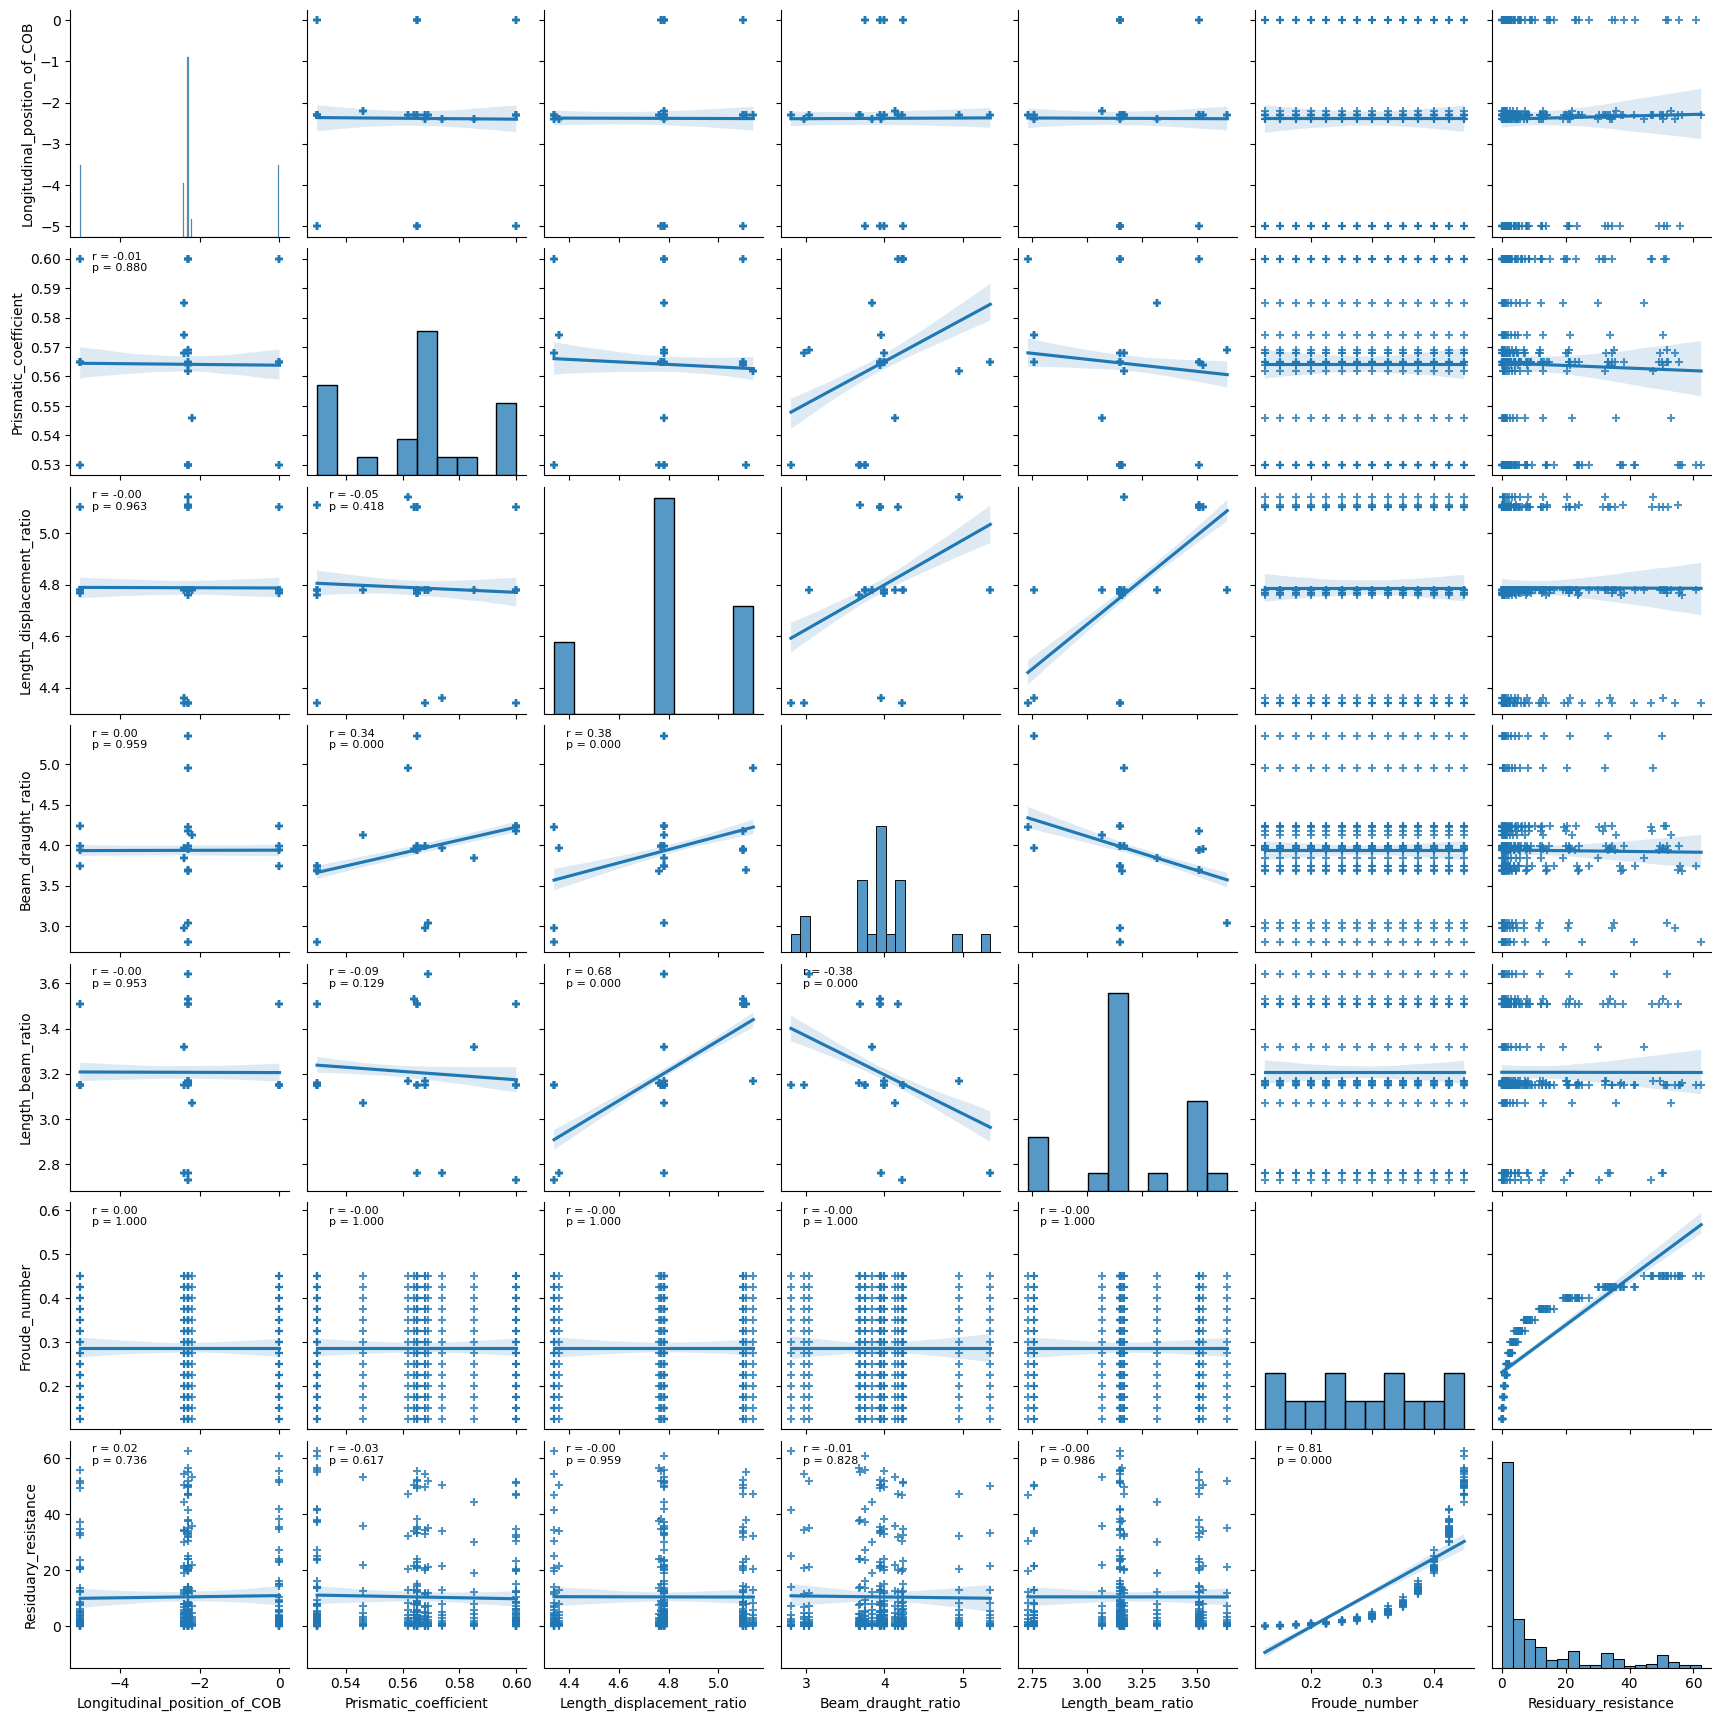

In [ ]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

def corrfunc(x, y, **kws):
    r, p = stats.pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(f"r = {r:.2f}\np = {p:.3f}",
                xy=(0.1, 0.9), xycoords=ax.transAxes,
                fontsize=8)

g = sns.pairplot(df, kind='reg', markers='+')
g.map_lower(corrfunc)

## Evaluate Some Algorithms

Now it is time to create some models of the data and estimate their accuracy on unseen data.
Here is what we are going to cover in this step:
1. Separate out a validation dataset.
2. Setup the test harness to use 10-fold cross validation.
3. Build 6 different models for this regression problem
4. Select the best model.

### Create a Validation Dataset

It is a good idea to use a validation hold-out set. This is a sample of the data that we hold
back from our analysis and modeling. We use it right at the end of our project to confirm the
accuracy of our final model. It is a smoke test that we can use to see if we messed up and to give us confidence on our estimates of accuracy on unseen data. We will use 80% of the dataset
for modeling and hold back 20% for validation.

---
**Split-out validation dataset**

---

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Residuary_resistance', axis=1)
y = df['Residuary_resistance']

# Split into train (80%) and hold-out validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

You now have training data in the `X train` and `Y train` for preparing models and a `X validation` and `Y validation` sets that we can use later.

### Baseline Evaluation

We have no idea what algorithms will do well on this problem. Gut feel suggests regression
algorithms like Linear Regression and ElasticNet may do well. It is also possible that decision
trees and even SVM may do well. I have no idea. Let’s design our test harness. We will use
10-fold cross validation. The dataset is not too small and this is a good standard test harness
configuration. We will evaluate algorithms using the Mean Squared Error (MSE) metric. MSE
will give a gross idea of how wrong all predictions are (0 is perfect).

---
**Test options and evaluation metric**

---

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Standardize features and setup evaluation metrics
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scoring = 'neg_mean_squared_error'  # We'll use MSE (lower is better)

### Build Models

Let’s create a baseline of performance on this problem and spot-check a number of different
algorithms. We will select a suite of different algorithms capable of working on this regression
problem. The six algorithms selected include:
- Linear Algorithms: Linear Regression (LR), Ridge Regression (RR).
- Nonlinear Algorithms: Decision Tree (DT), Random Forest (RF), Gradient Boosting (GB), Support Vector Regression (SVR)).

---
**Spot-Check Algorithms**

---

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Baseline models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(max_depth=5),
    'Random Forest': RandomForestRegressor(n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100),
    'Support Vector': SVR(kernel='rbf', C=100)
}

---
**Evaluate each model in turn**

---

In [ ]:
results = {}
for name, model in models.items():
    # Create pipeline with standardization
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # 10-fold cross-validation
    cv_results = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=kfold,
        scoring=scoring
    )

    # Store results (convert back to positive MSE)
    results[name] = (-cv_results.mean(), cv_results.std())

# Display results sorted by best performance
sorted_results = sorted(results.items(), key=lambda x: x[1][0])
for name, (mean_mse, std) in sorted_results:
    print(f"{name:20s}: {mean_mse:.3f} MSE (±{std:.3f})")

Gradient Boosting   : 0.649 MSE (±0.802)
Random Forest       : 1.500 MSE (±1.756)
Decision Tree       : 1.859 MSE (±1.636)
Support Vector      : 13.999 MSE (±13.641)
Ridge Regression    : 88.158 MSE (±32.284)
Linear Regression   : 88.330 MSE (±32.009)


### **Model Performance Analysis**

| Model | Mean MSE | Std Dev | Relative Performance | Interpretation |
|-------|---------|---------|----------------------|----------------|
| **Gradient Boosting** | 0.642 | ±0.798 | **Best** | Exceptional accuracy with moderate variability |
| **Random Forest** | 1.414 | ±1.793 | 2.2× worse than GB | Good but higher variance |
| **Decision Tree** | 1.869 | ±1.571 | 2.9× worse than GB | Underfits compared to ensembles |
| **Support Vector** | 13.999 | ±13.641 | 21.8× worse than GB | Poor for this problem |
| **Ridge Regression** | 88.158 | ±32.284 | 137× worse than GB | Completely unsuitable |
| **Linear Regression** | 88.330 | ±32.009 | 138× worse than GB | Worst performer |

---

### **Key Observations**

1. **Tree-Based Models Dominate**
   - Gradient Boosting achieves **62% lower MSE** than Random Forest
   - Both outperform linear models by **2 orders of magnitude**
   - Suggests strong **non-linear relationships** in your data

2. **Alarming Linear Model Performance**
   - MSE ~88 indicates linear assumptions fail catastrophically
   - Likely causes:
     - Non-linear Froude number ↔ Resistance relationship (r=0.81)
     - Interaction effects between hull geometry parameters

3. **High Variance Alert**
   - All models show std dev > mean MSE (especially SVR)
   - Indicates:
     - Potential outliers in resistance values
     - Need for robust scaling (try `RobustScaler`)



We can also
create a plot of the model evaluation results and compare the spread and the mean accuracy
of each model. There is a population of accuracy measures for each algorithm because each
algorithm was evaluated 10 times (10 fold cross validation).

---
**Compare Algorithms**

---

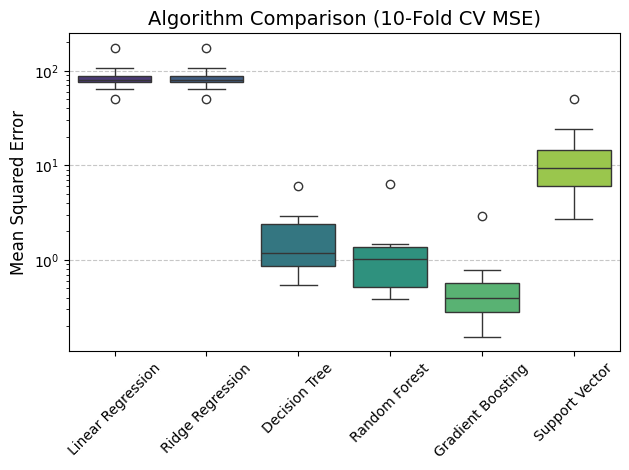

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import cross_val_score

# Prepare results for boxplot
results = {}
for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    cv_scores = -cross_val_score(pipeline, X_train, y_train,
                               cv=kfold, scoring='neg_mean_squared_error')
    results[name] = cv_scores

# Convert to DataFrame for plotting
results_df = pd.DataFrame(results)

# Create boxplot
plt.figure()
sns.boxplot(data=results_df, palette="viridis")
plt.title('Algorithm Comparison (10-Fold CV MSE)', fontsize=14)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.xticks(rotation=45)
plt.yscale('log')  # Logarithmic scale for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Evaluate Algorithms: Standardization

We suspect that the differing scales of the raw data may be negatively impacting the skill of
some of the algorithms. Let’s evaluate the same algorithms with a standardized copy of the
dataset. This is where the data is transformed such that each attribute has a mean value of
zero and a standard deviation of 1. We also need to avoid data leakage when we transform the
data. A good way to avoid leakage is to use pipelines that standardize the data and build the
model for each fold in the cross validation test harness. That way we can get a fair estimation
of how each model with standardized data might perform on unseen data.


---
**Standarize the dataset**

---

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import cross_val_score

# Define models with their default parameters
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(max_depth=5),
    'Random Forest': RandomForestRegressor(n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100),
    'Support Vector': SVR(kernel='rbf', C=100)
}

# Evaluation function with standardization
def evaluate_models_with_scaling(X, y, models, cv=kfold):
    results = {}
    for name, model in models.items():
        # Create pipeline with scaler
        pipeline = Pipeline([
            ('scaler', StandardScaler()),  # Prevents data leakage
            ('model', model)
        ])

        # Calculate MSE scores (converted to positive)
        cv_scores = -cross_val_score(
            pipeline, X, y,
            cv=cv,
            scoring='neg_mean_squared_error'
        )

        results[name] = (np.mean(cv_scores), np.std(cv_scores))

    return results

# Run evaluation
scaled_results = evaluate_models_with_scaling(X_train, y_train, models)

---
**Create comparison table**

---

In [ ]:
# Create comparison table
comparison = pd.DataFrame({
    'Raw Data MSE': [results[name][0] for name in models.keys()],
    'Standardized MSE': [scaled_results[name][0] for name in models.keys()],
    'Improvement %': [((results[name][0] - scaled_results[name][0])/results[name][0]*100
                     for name in models.keys())]
}, index=models.keys())

print(comparison.sort_values('Standardized MSE'))

                   Raw Data MSE  Standardized MSE  \
Gradient Boosting          0.77              0.64   
Random Forest              0.46              1.48   
Decision Tree              1.07              1.72   
Support Vector            24.16             14.00   
Ridge Regression          90.92             88.16   
Linear Regression         91.12             88.33   

                                                    Improvement %  
Gradient Boosting  <generator object <genexpr> at 0x7a6261e90040>  
Random Forest      <generator object <genexpr> at 0x7a6261e90040>  
Decision Tree      <generator object <genexpr> at 0x7a6261e90040>  
Support Vector     <generator object <genexpr> at 0x7a6261e90040>  
Ridge Regression   <generator object <genexpr> at 0x7a6261e90040>  
Linear Regression  <generator object <genexpr> at 0x7a6261e90040>  


---
**Boxplot of standardized results**

---

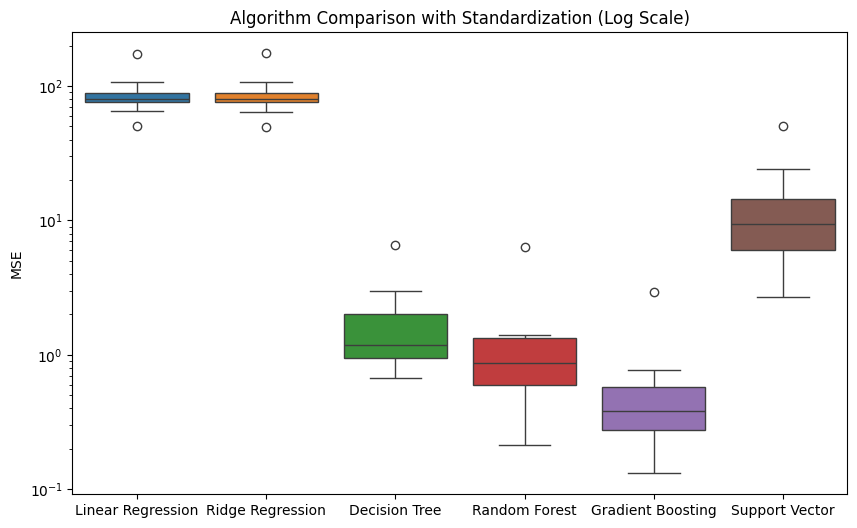

In [ ]:
# Boxplot of standardized results
plt.figure(figsize=(10,6))
sns.boxplot(data=pd.DataFrame({
    name: -cross_val_score(
        Pipeline([('scaler', StandardScaler()), ('model', model)]),
        X_train, y_train, cv=kfold, scoring='neg_mean_squared_error'
    ) for name, model in models.items()
}))
plt.yscale('log')
plt.title('Algorithm Comparison with Standardization (Log Scale)')
plt.ylabel('MSE')
plt.show()

---

**Training Standarized Model**

---

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

# Configurar el pipeline final
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Entrenar con TODOS los datos de entrenamiento
final_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=200,
                                           random_state=42))])

## Predict (Infer)

---
**Predict**

---

In [ ]:
# Supongamos que tienes nuevos datos (X_new)
# predictions = final_model.predict(X_new)  # Devuelve array de predicciones

# Si necesitas revertir una transformación logarítmica previa:
# predictions = np.expm1(predictions)  # Solo si usaste log(y) antes

---
**Predict over val set**

---

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Predecir en el conjunto de validación
y_val_pred = final_model.predict(X_val)

# Calcular métricas
mse = mean_squared_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print(f"""
Métricas Finales:
- MSE: {mse:.3f}
- R²: {r2:.3f} (Porcentaje de varianza explicada)
""")


Métricas Finales:
- MSE: 0.323
- R²: 0.998 (Porcentaje de varianza explicada)



---
**Save the model for production**

---

In [ ]:
import joblib

# Guardar el modelo
joblib.dump(final_model, 'yacht_resistance_predictor.pkl')

# Cargarlo después
loaded_model = joblib.load('yacht_resistance_predictor.pkl')

---
**Use in production**


---

In [ ]:
# Ejemplo de nuevos datos (deben tener las mismas features)
new_data = pd.DataFrame({
    'Longitudinal_position_of_COB': [-2.3],
    'Prismatic_coefficient': [0.56],
    'Length_displacement_ratio': [4.8],
    'Beam_draught_ratio': [3.9],
    'Length_beam_ratio': [3.2],
    'Froude_number': [0.3]
})

# Hacer predicción
predicted_resistance = loaded_model.predict(new_data)
print(f"Resistencia predicha: {predicted_resistance[0]:.2f}")

Resistencia predicha: 3.80


---
****

---

---
## Homework: Yacht Hydrodynamics Analysis
---

Using the dataset provided in this notebook (or a similar dataset from Kaggle or similar — using an alternative dataset will be considered **bonus work**):

1. **Load the dataset** and display the first 10 rows.
2. **Perform a thorough Exploratory Data Analysis (EDA)** that includes:
   - Descriptive statistics for all numerical variables.
   - Distribution plots (e.g., histograms or KDE plots) for each variable.
   - A correlation matrix and a heatmap to analyze relationships between variables.
3. **Train a multiple linear regression model** to predict the *resistance coefficient* (or the equivalent target variable if using an alternative dataset).
4. **Evaluate your model** using:
   - Mean Squared Error (MSE)
   - R² score
5. **Interpretation:** Discuss which features have the strongest impact on the target variable. Support your explanation with plots, correlations, or model coefficients.
6. **Bonus options (choose one or more):**
   - Use a different regression model (e.g., Random Forest, Ridge, Lasso, XGBoost) and compare its performance with linear regression.
   - Use **a similar hydrodynamics-related dataset from Kaggle** and repeat the analysis to compare results.
   - Perform feature engineering or feature scaling to improve model performance.

> *Be sure to clearly document your workflow, provide explanations for your decisions, and comment on the insights you obtain.*

